In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
base_path = "/content/drive/MyDrive/DSC106_final_project/Data/"

steam = pd.read_csv(base_path + "steam.csv")

In [ ]:
len(steam)

27075

In [ ]:
steam.columns

Index(['appid', 'name', 'release_date', 'english', 'developer', 'publisher',
       'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags',
       'achievements', 'positive_ratings', 'negative_ratings',
       'average_playtime', 'median_playtime', 'owners', 'price'],
      dtype='object')

In [ ]:
steam = steam.dropna(subset=[
    'positive_ratings',
    'negative_ratings',
    'price',
    'genres'
])

steam['total_ratings'] = (
    steam['positive_ratings'] +
    steam['negative_ratings']
)

steam['rating_ratio'] = (
    steam['positive_ratings'] /
    steam['total_ratings']
)

steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,total_ratings,rating_ratio
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19,127873,0.973888
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99,3951,0.839787
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,3814,0.895648
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,1540,0.826623
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99,5538,0.947996


Top 10 Genres

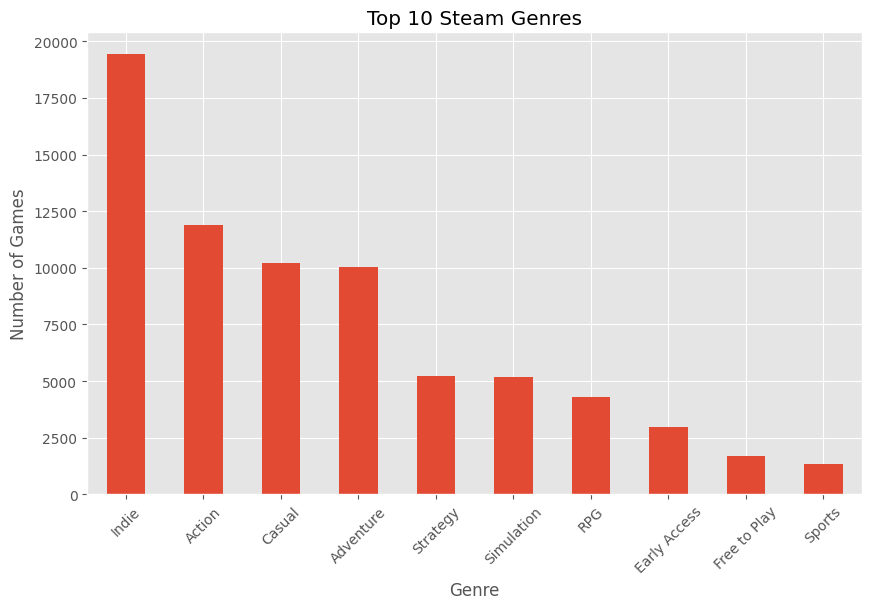

In [ ]:
top_genres = (
    steam['genres']
    .str.split(';')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_genres.plot(kind='bar')

plt.title('Top 10 Steam Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Games')

plt.xticks(rotation=45)

plt.show()

Price vs Rating

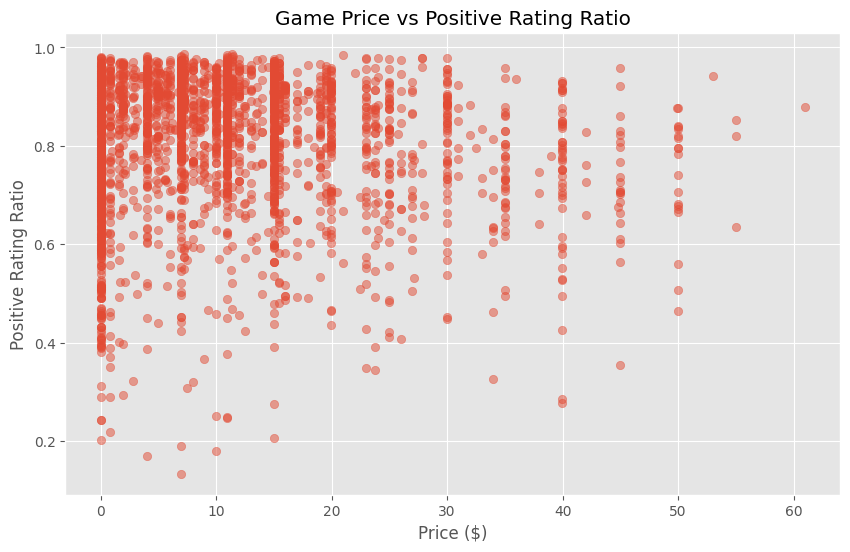

In [ ]:
popular_games = steam[
    steam['total_ratings'] > 1000
]

plt.figure(figsize=(10,6))

plt.scatter(
    popular_games['price'],
    popular_games['rating_ratio'],
    alpha=0.5
)

plt.title('Game Price vs Positive Rating Ratio')
plt.xlabel('Price ($)')
plt.ylabel('Positive Rating Ratio')

plt.show()

Steam Growth Over Time

In [ ]:
steam['release_date'] = pd.to_datetime(
    steam['release_date'],
    errors='coerce'
)

steam['release_year'] = (
    steam['release_date'].dt.year
)

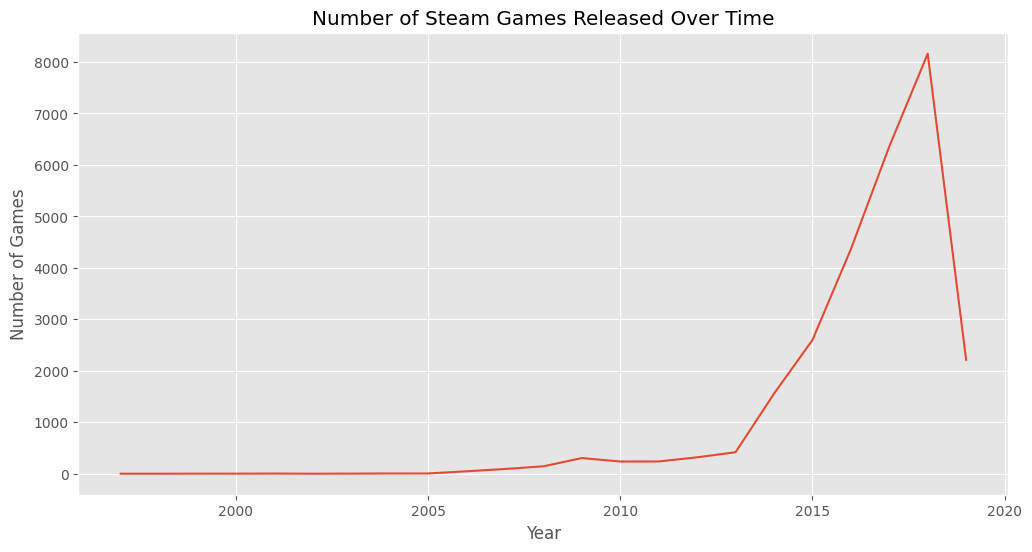

In [ ]:
games_per_year = (
    steam['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

games_per_year.plot()

plt.title('Number of Steam Games Released Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Games')

plt.show()

Free vs Paid Games

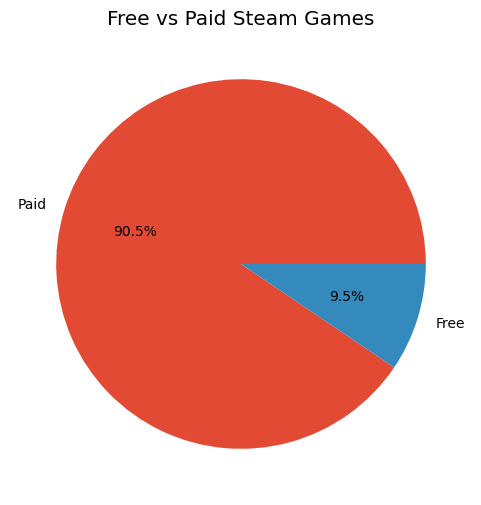

In [ ]:
steam['is_free'] = steam['price'] == 0

free_counts = steam['is_free'].value_counts()

labels = ['Paid', 'Free']

plt.figure(figsize=(6,6))

plt.pie(
    free_counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Free vs Paid Steam Games')

plt.show()

Top Developers

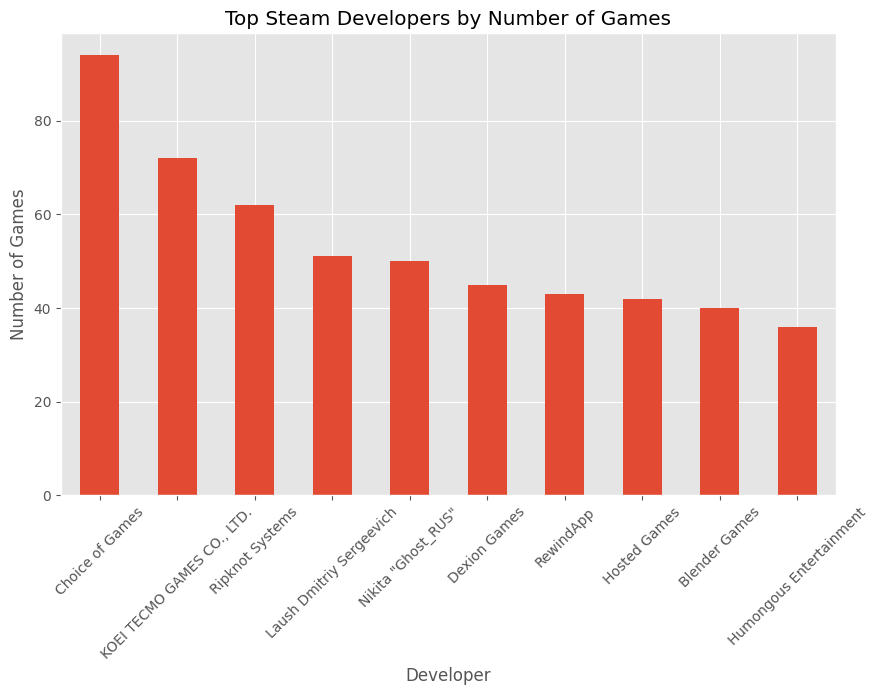

In [ ]:
top_developers = (
    steam['developer']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_developers.plot(kind='bar')

plt.title('Top Steam Developers by Number of Games')
plt.xlabel('Developer')
plt.ylabel('Number of Games')

plt.xticks(rotation=45)

plt.show()


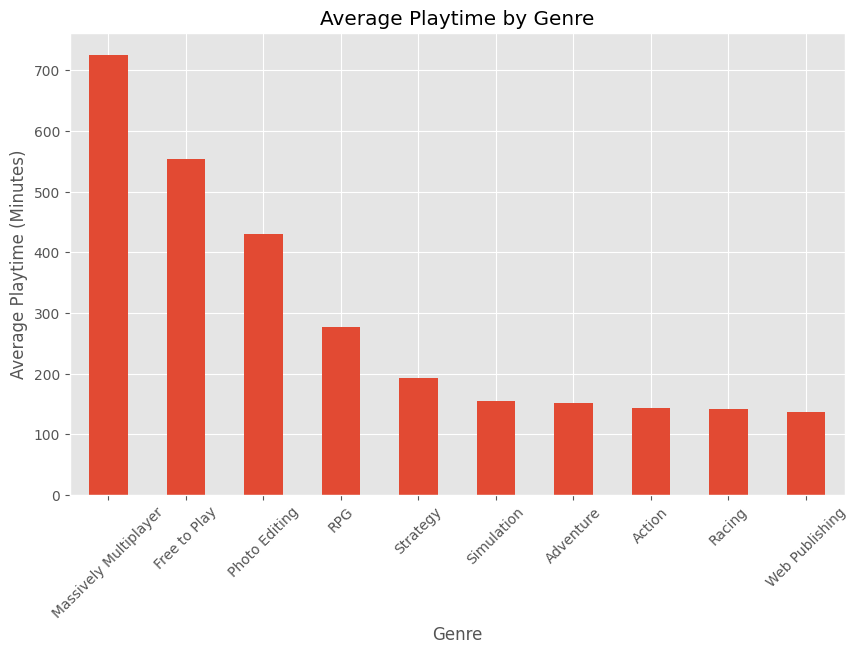

In [ ]:
# Split genres into individual rows
genre_playtime = (
    steam.assign(genres=steam['genres'].str.split(';'))
    .explode('genres')
)

# Calculate average playtime per genre
avg_playtime = (
    genre_playtime.groupby('genres')['average_playtime']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Create visualization
plt.figure(figsize=(10,6))

avg_playtime.plot(kind='bar')

plt.title('Average Playtime by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Playtime (Minutes)')

plt.xticks(rotation=45)

plt.show()